# 02 Turnover Detection and Single-Episode GNN PoC

Notebook ini membuktikan alur awal pada pertandingan J03WPY: perubahan penguasaan saat bola aktif, window tracking, graph pemain-bola, konversi PyTorch Geometric, dan forward pass GCN. Sampel yang dipakai tetap candidate pertama, frame 10252.

Metodologi yang dipertahankan:
- turnover candidate: perubahan `ball_owning_team_id` ketika `ball_state == 'alive'`;
- window: `T0-2s` sampai `T0+2s` pada 25 Hz, sehingga 101 frame;
- node: 22 pemain aktif dan satu bola;
- edge: directed k-nearest neighbors dengan `k=4`;
- fitur node: posisi, speed, indikator bola, dan dua indikator tim;
- model: dua GCN layer, mean pooling per frame, lalu mean aggregation terhadap waktu.

Penyesuaian yang dijelaskan: indikator tim absolut `team_A/team_B` diganti menjadi `is_losing_team/is_opponent`. Dimensi fitur tetap enam, tetapi representasi dapat dipakai pada pertandingan lain. Jarak edge kini disimpan sebagai `edge_attr`, walaupun model GCN PoC ini belum menggunakannya. Logit terakhir berasal dari model yang belum dilatih dan bukan prediksi.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.idsse_episode_dataset import (
    EpisodeSampleConfig,
    build_episode_sample,
    detect_turnover_candidates,
    load_match,
)

MATCH_ID = 'J03WPY'
DATA_DIR = PROJECT_ROOT / 'data' / 'sportec_idsse'
CONFIG = EpisodeSampleConfig(
    pre_seconds=2.0,
    post_seconds=2.0,
    regain_horizon_seconds=5.0,
    frame_rate_hz=25,
    k_neighbors=4,
)
tracking, events = load_match(DATA_DIR, MATCH_ID)
print('Tracking shape:', tracking.shape)
print('Events shape  :', events.shape)
print('Expected frames:', CONFIG.expected_frame_count)

Tracking shape: (146211, 133)
Events shape  : (1572, 19)
Expected frames: 101


In [2]:
candidates = detect_turnover_candidates(
    tracking,
    MATCH_ID,
    regain_horizon_seconds=CONFIG.regain_horizon_seconds,
)
candidate_summary = pd.Series({
    'active_possession_changes': len(candidates),
    'quick_regain_5s': int(candidates['label_regain_5s'].sum()),
    'no_quick_regain_5s': int((candidates['label_regain_5s'] == 0).sum()),
}, name='count')
display(candidate_summary.to_frame())

selected_event = candidates.iloc[0].to_dict()
display(pd.Series({
    'candidate_id': selected_event['candidate_id'],
    'period_id': selected_event['period_id'],
    'loss_timestamp': selected_event['loss_timestamp'],
    'loss_frame': selected_event['loss_frame'],
    'losing_team': selected_event['losing_team'],
    'opponent_team': selected_event['opponent_team'],
    'quick_regain_success': selected_event['label_regain_5s'],
    'regain_gap_seconds': selected_event['regain_gap_seconds'],
}, name='selected_episode').to_frame())

events_context = events.copy()
events_context['timestamp'] = pd.to_timedelta(
    events_context['timestamp'], errors='coerce'
)
context_radius = pd.Timedelta(5, unit='s')
event_context = events_context[
    events_context['period_id'].eq(int(selected_event['period_id']))
    & events_context['timestamp'].between(
        selected_event['loss_timestamp'] - context_radius,
        selected_event['loss_timestamp'] + context_radius,
    )
].sort_values(['timestamp', 'event_id'])
display(event_context[[
    'timestamp', 'event_type', 'team_id', 'player_id',
    'receiver_player_id', 'success',
]])

,count
active_possession_changes,324
quick_regain_5s,148
no_quick_regain_5s,176


,selected_episode
candidate_id,J03WPY_P1_F10252
period_id,1
loss_timestamp,0 days 00:00:10.080000
loss_frame,10252
losing_team,DFL-CLU-00000P
opponent_team,DFL-CLU-000005
quick_regain_success,0
regain_gap_seconds,NaN


,timestamp,event_type,team_id,player_id,receiver_player_id,success
3,0 days 00:00:06.465000,PASS,DFL-CLU-00000P,DFL-OBJ-002FXT,NaN,False
4,0 days 00:00:11.553000,PASS,DFL-CLU-000005,DFL-OBJ-0001HW,DFL-OBJ-002G68,True


In [3]:
sample = build_episode_sample(
    selected_event,
    tracking,
    events,
    config=CONFIG,
    materialize_graphs=True,
)
display(pd.Series(sample['audit'], name='value').to_frame())

pyg_sequence = []
for frame_idx in range(len(sample['frame_ids'])):
    pyg_sequence.append(Data(
        x=torch.from_numpy(sample['node_features'][frame_idx]),
        edge_index=torch.from_numpy(sample['edge_index'][frame_idx]),
        edge_attr=torch.from_numpy(sample['edge_attr'][frame_idx]),
        pos=torch.from_numpy(sample['node_features'][frame_idx, :, :2]),
        node_mask=torch.from_numpy(sample['node_mask'][frame_idx]),
        y=torch.tensor([sample['label']], dtype=torch.long),
    ))

print('Node feature names: x, y, speed, is_ball, is_losing_team, is_opponent')
print('Node feature array:', sample['node_features'].shape)
print('Node mask array   :', sample['node_mask'].shape)
print('Relative time     :', sample['relative_times'][0], 'to', sample['relative_times'][-1])
print('PyG graphs        :', len(pyg_sequence))
for frame_idx in (0, len(pyg_sequence) // 2, len(pyg_sequence) - 1):
    graph = pyg_sequence[frame_idx]
    print(
        f"Frame {int(sample['frame_ids'][frame_idx])}: "
        f"x={tuple(graph.x.shape)}, "
        f"edges={tuple(graph.edge_index.shape)}, "
        f"edge_attr={tuple(graph.edge_attr.shape)}"
    )

,value
candidate_id,J03WPY_P1_F10252
match_id,J03WPY
period_id,1
loss_frame,10252
loss_timestamp,0 days 00:00:10.080000
label_regain_5s,0
frame_count,101
expected_frame_count,101
active_player_count,22
losing_player_count,11


Node feature names: x, y, speed, is_ball, is_losing_team, is_opponent
Node feature array: (101, 23, 6)
Node mask array   : (101, 23)
Relative time     : -2.0 to 2.0
PyG graphs        : 101
Frame 10202: x=(23, 6), edges=(2, 92), edge_attr=(92, 1)
Frame 10252: x=(23, 6), edges=(2, 92), edge_attr=(92, 1)
Frame 10302: x=(23, 6), edges=(2, 92), edge_attr=(92, 1)


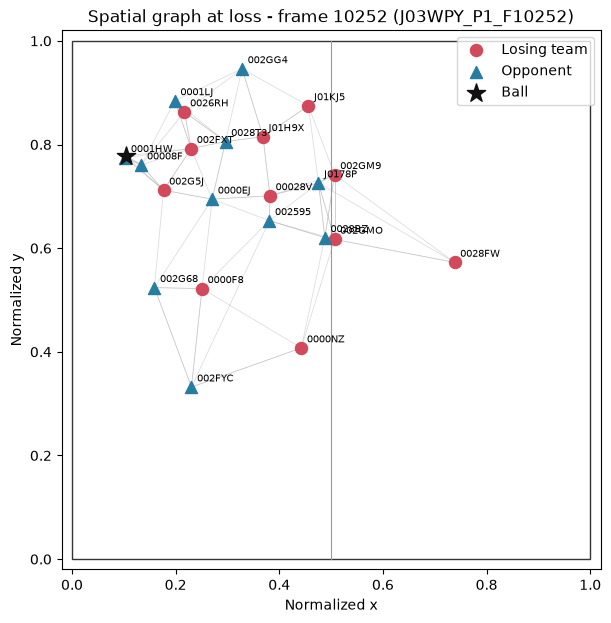

In [4]:
loss_idx = int(np.argmin(np.abs(sample['relative_times'])))
positions = sample['node_features'][loss_idx, :, :2]
features = sample['node_features'][loss_idx]
edge_index = sample['edge_index'][loss_idx]
losing_mask = features[:, 4].astype(bool)
opponent_mask = features[:, 5].astype(bool)
ball_mask = features[:, 3].astype(bool)

fig, ax = plt.subplots(figsize=(11, 7))
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, color='#333333'))
ax.plot([0.5, 0.5], [0, 1], color='#999999', linewidth=0.8)
for source, target in edge_index.T:
    ax.plot(
        positions[[source, target], 0],
        positions[[source, target], 1],
        color='#B0B0B0', linewidth=0.55, alpha=0.45, zorder=1,
    )
ax.scatter(
    positions[losing_mask, 0], positions[losing_mask, 1],
    s=75, c='#D1495B', marker='o', label='Losing team', zorder=3,
)
ax.scatter(
    positions[opponent_mask, 0], positions[opponent_mask, 1],
    s=75, c='#277DA1', marker='^', label='Opponent', zorder=3,
)
ax.scatter(
    positions[ball_mask, 0], positions[ball_mask, 1],
    s=190, c='#111111', marker='*', label='Ball', zorder=4,
)
for node_idx, node_id in enumerate(sample['node_ids'][:-1]):
    ax.annotate(
        node_id.replace('DFL-OBJ-', ''),
        positions[node_idx], xytext=(4, 4),
        textcoords='offset points', fontsize=7,
    )
ax.set(
    xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
    xlabel='Normalized x', ylabel='Normalized y',
    title=(
        f"Spatial graph at loss - frame {int(sample['frame_ids'][loss_idx])} "
        f"({sample['candidate_id']})"
    ),
)
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.show()

In [5]:
class GNNPoC(nn.Module):
    def __init__(self, in_channels=6, hidden_channels=32, output_channels=2):
        super().__init__()
        self.gcn1 = GCNConv(in_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, output_channels)

    def forward(self, graph_sequence):
        frame_embeddings = []
        for graph in graph_sequence:
            h = F.relu(self.gcn1(graph.x, graph.edge_index))
            h = F.relu(self.gcn2(h, graph.edge_index))
            frame_embeddings.append(h.mean(dim=0))
        temporal_embedding = torch.stack(frame_embeddings)
        final_embedding = temporal_embedding.mean(dim=0)
        return self.classifier(final_embedding), final_embedding

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNPoC().to(device)
graph_sequence_device = [graph.to(device) for graph in pyg_sequence]
model.eval()
with torch.no_grad():
    logits, embedding = model(graph_sequence_device)

print('Device         :', device)
print('Logit shape    :', tuple(logits.shape))
print('Embedding shape:', tuple(embedding.shape))
print('Untrained logits:', logits.detach().cpu())
print('Catatan: logits ini hanya membuktikan forward pass, bukan prediksi.')

Device         : cuda
Logit shape    : (2,)
Embedding shape: (32,)
Untrained logits: tensor([ 0.1775, -0.6400])
Catatan: logits ini hanya membuktikan forward pass, bukan prediksi.
